My Instagram Data Report

Emerson Weiss-Vopat

09/18/26

This data is of my own personal Instagram account, specifically one I used to stay connected to various underground music scenes. The source of this data is partly from my own actions (such as posts or likes), but also from Instagram monitoring my behaviors/general tracking. 

This data was created to be able to see how users interact with the platform. Outside of getting a better understanding of the behavior of users, it can also be used for advertising and to boost engagement (e.g. algorithms). 

This data is reliable in part due to the accuracy in the data that is given, especially when it comes to specific likes/posts.

This data is unreliable a lot in part due to the fact that it is not everything the platform collects on the user.

In [1]:
import json
import pandas as pd

with open('liked_posts2.json', 'r') as f:
    data = json.load(f)

data[0]

{'timestamp': 1779423645,
 'media': [],
 'label_values': [{'label': 'URL',
   'value': 'https://www.instagram.com/p/DYkb5xNRJ5-/',
   'href': 'https://www.instagram.com/p/DYkb5xNRJ5-/'},
  {'label': 'Caption', 'value': 'SWALLOW THE SOIL.\n\nFRIDAY.'},
  {'label': 'Title', 'value': ''},
  {'dict': [], 'title': 'Hashtags'},
  {'dict': [{'dict': [{'label': 'URL', 'value': 'https://linktr.ee/nimda_uk'},
      {'label': 'Name', 'value': 'NIMDA'},
      {'label': 'Username', 'value': 'nimda_uk'}],
     'title': ''}],
   'title': 'Owner'},
  {'dict': [], 'title': 'Brand partner'}],
 'fbid': '18015128204752534'}

In [2]:
row = {}
row['timestamp'] = data[0]['timestamp']

row

{'timestamp': 1779423645}

In [3]:
for item in data[0]['label_values']:
    if 'label' in item:
        row[item['label']] = item['value']

row

{'timestamp': 1779423645,
 'URL': 'https://www.instagram.com/p/DYkb5xNRJ5-/',
 'Caption': 'SWALLOW THE SOIL.\n\nFRIDAY.',
 'Title': ''}

In [4]:
for item in data[0]['label_values']:
    if 'label' in item:
        row[item['label']] = item['value']
    elif item.get('title') == 'Owner': 
        owner_fields = item['dict'][0]['dict']
        for owner_item in owner_fields:
            row['Owner' + owner_item['label']] = owner_item['value']

row

{'timestamp': 1779423645,
 'URL': 'https://www.instagram.com/p/DYkb5xNRJ5-/',
 'Caption': 'SWALLOW THE SOIL.\n\nFRIDAY.',
 'Title': '',
 'OwnerURL': 'https://linktr.ee/nimda_uk',
 'OwnerName': 'NIMDA',
 'OwnerUsername': 'nimda_uk'}

In [5]:
tidy_rows = []

for entry in data:
    row = {}
    row['timestamp'] = entry['timestamp']

    for item in entry['label_values']:
        if 'label' in item:
            row[item['label']] = item['value']
        elif item.get('title') == 'Owner':
            owner_fields = item['dict'][0]['dict']
            for owner_item in owner_fields:
                row['Owner' + owner_item['label']] = owner_item['value']
    tidy_rows.append(row)

tidy_rows[:2]

[{'timestamp': 1779423645,
  'URL': 'https://www.instagram.com/p/DYkb5xNRJ5-/',
  'Caption': 'SWALLOW THE SOIL.\n\nFRIDAY.',
  'Title': '',
  'OwnerURL': 'https://linktr.ee/nimda_uk',
  'OwnerName': 'NIMDA',
  'OwnerUsername': 'nimda_uk'},
 {'timestamp': 1778782655,
  'URL': 'https://www.instagram.com/reel/DYUtKDVTfms/',
  'Caption': 'TABARNAK\n\nSINISTER / ASSAILANT \n\nTOMORROW',
  'Title': '',
  'OwnerURL': 'https://linktr.ee/APOCRECS',
  'OwnerName': '',
  'OwnerUsername': 'apocrypharecs'}]

In [6]:
likes_df = pd.DataFrame(tidy_rows)
likes_df.head(10)

,timestamp,URL,Caption,Title,OwnerURL,OwnerName,OwnerUsername
0,1779423645,https://www.instagram.com/p/DYkb5xNRJ5-/,SWALLOW THE SOIL.\n\nFRIDAY.,,https://linktr.ee/nimda_uk,NIMDA,nimda_uk
1,1778782655,https://www.instagram.com/reel/DYUtKDVTfms/,TABARNAK\n\nSINISTER / ASSAILANT \n\nTOMORROW,,https://linktr.ee/APOCRECS,,apocrypharecs
2,1778218604,https://www.instagram.com/p/DYC3HhEDzpP/,Youâre invited to the SUBSISTENCE premiere! ...,,https://linktr.ee/digitist,DIGITIST,digitistdubs
3,1771529250,https://www.instagram.com/p/DU8uMNcjw4O/,ð¼ ð,,https://ericdoa.ffm.to/agoraphobia,,ericdoa
4,1768581173,https://www.instagram.com/p/DTjUy6WEmKR/,WHOâS HYPED FOR THIS RELEASE?,,https://ffm.bio/manly,MANLY,manly.music
5,1767859188,https://www.instagram.com/p/DTI83YrDWpw/,LIMITLESS PERIL. LIVE.,,https://linktr.ee/nimda_uk,NIMDA,nimda_uk
6,1766476072,https://www.instagram.com/p/DSlO8JlErm7/,2026 Showcase\n\nDropping in about an hour,,http://soundcloud.com/iamdamori/impermanence-1,Damori,i_am_damori
7,1766475890,https://www.instagram.com/p/DSdEY0jAhZP/,HEAD GONE - OUT NOW,,https://open.spotify.com/artist/2rx1yiRvSJFvlu...,,stvgx_
8,1766139998,https://www.instagram.com/p/DSa6Qw4Ehu3/,PRESENTING: PRECURSOR II\n\n6 tracks from the ...,,https://linktr.ee/digitist,DIGITIST,digitistdubs
9,1765991998,https://www.instagram.com/p/DSP6thKCIYk/,1 YEAR OF HOFW.\n\nSPLIT EP OUT NOW VIA @dazeo...,,https://linktr.ee/houndsofwar_gthc,HOUNDS OF WAR,houndsofwar_gthc


In [7]:
likes_df['DateTime'] = pd.to_datetime(likes_df['timestamp'], unit='s')
likes_df[['timestamp', 'DateTime']].head()

,timestamp,DateTime
0,1779423645,2026-05-22 04:20:45
1,1778782655,2026-05-14 18:17:35
2,1778218604,2026-05-08 05:36:44
3,1771529250,2026-02-19 19:27:30
4,1768581173,2026-01-16 16:32:53


In [8]:
likes_df.shape

(1612, 8)

In [9]:
likes_df['OwnerUsername'].isna().sum()

np.int64(0)

In [10]:
likes_df.dtypes

timestamp                int64
URL                        str
Caption                    str
Title                      str
OwnerURL                   str
OwnerName                  str
OwnerUsername              str
DateTime         datetime64[s]
dtype: object

In [11]:
likes_df.groupby("OwnerUsername")["DateTime"].count()

OwnerUsername
00guh203             1
00piumunderground    3
0verrated_cringe     1
1kkdeee              1
1multimedia2012      1
                    ..
zayesxo              1
zenftc               1
zestyponmemes        1
zippitmister         1
zootedoffthepercs    2
Name: DateTime, Length: 996, dtype: int64

In [12]:
likes_by_account = (
    likes_df.groupby("OwnerUsername")["DateTime"]
    .count()
    .sort_values(ascending=False)
)
likes_by_account.head(10)

OwnerUsername
cal.mcs                    82
hyperpopdaily              36
interval_audio             18
sisto_official             16
gdhndcllctv                13
reel.postz                 13
maraudamusic               10
davidsonolvr               10
howitfeelstochewfivegum    10
ericdoa                    10
Name: DateTime, dtype: int64

Initially, I was going to to test out of all the posts I've liked, how many I commented under. Seeing as the post_comments JSON file would contain my actual comments and also the account/post that I commented under. However, I ran into some trouble getting the information I needed from the file, and realized I would be making the assumption that all of the posts I commented under are posts I've liked, which is not necessarily true. My new hypothesis is as follows:

My follower count is less than my following count.

In order to accomplish this, I am using the following.json and followers.json files because they contain data regarding the accounts that I follow, and that follow me.

I will find the total number of accounts that follow me, and that I follow (from the two JSON files), and compare said totals. If my hypothesis is correct, the total number of accounts I follow will be greater than the total number of accounts that follow me.

In [77]:
import json
import pandas as pd

In [78]:
with open('following2.json', 'r') as y:
    data = json.load(y)

In [79]:
with open('followers_1.json', 'r') as y:
    data2 = json.load(y)

In [80]:
following2_df = pd.DataFrame(data['relationships_following'])

In [81]:
followers_1_df = pd.DataFrame({
    'username': [item['string_list_data'][0]['value'] for item in data2]
})

In [82]:
following2_df = following2_df[['title']]
following2_df = following2_df.rename(columns={'title': 'username'})

In [83]:
followers_1_df.head(10)

,username
0,krishna_nishad_raj__________01
1,ajimsaiyad1
2,alvazs
3,sadhu44946
4,sonu_kumarqqkk
5,sk6494903
6,84529_96597
7,pagal__chhora__302__307
8,krishna_____mukhiay
9,rekha49800


In [84]:
following2_df.head(10)

,username
0,mirar_officiel
1,kkbinks
2,backroomsmovie
3,lucybedroque
4,akchamel_
5,harrowed_audio
6,synldn_uk
7,lizdekmusic
8,theportzero
9,kerosenedubz


In [85]:
print("Following:", len(following2_df))
print("Followers:", len(followers_1_df))

Following: 471
Followers: 36


<Axes: >

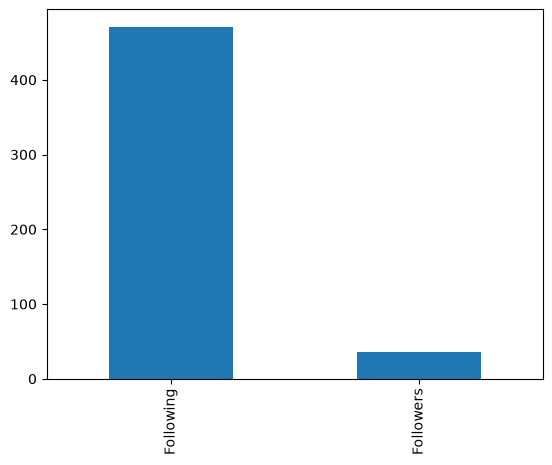

In [86]:
counts = {
    'Following': len(following2_df),
    'Followers': len(followers_1_df),
}

pd.Series(counts).plot(kind='bar')

In order to create this graph, I pulled from two different YouTube videos in order to help me, "Creating a Simple Bar Chart with Jupyter Notebook" by Ryan Noonan, and "Python - Simple Bar Chart" by stikpet. I still was a bit stuck even after the videos, but a classmate helped me fix it using "counts" rather than matplotlib or sourcing from another file (assuming I'm understanding what the videos showed correctly).

From analyzing this data, I have found that my hypothesis was correct. I follow more accounts than I have followers.

All in all, I did not have too difficult of a time completing this project (after I switched from my initial idea). However, I still do not fully understand the issues I had with making the graph originally. I am not sure there is much else I would have done differently for this hypothesis, but I do think a next step would be to showcase more data from these json files (such as date/time/# difference, etc.). I do think I should have renamed some of the JSON files I was working with, and change my naming conventions, because it resulted in a lot of wasted time.